In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%run '/content/drive/MyDrive/Repos/MachineLearning-ML001/helper/helper.ipynb'

### **Perceptron (Artificial Neuron)**

<p align="center">
  <img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch02/figures/02_04.png" width="600">
</p>

**1. The Core Concept:**

An artificial neuron acts as a binary classifier (predicting class 0 or 1). It calculates a net input ( 𝑧 ) via a linear combination of input features ( 𝐱 ) and corresponding weights ( 𝐰 ): $z = w_1x_1 + w_2x_2 + ... + w_mx_m$.

$$\mathbf{w} = \begin{bmatrix} w_1 \\ \vdots \\ w_m \end{bmatrix}, \quad \mathbf{x} = \begin{bmatrix} x_1 \\ \vdots \\ x_m \end{bmatrix}$$

**2. The Initial Decision Rule:**

The neuron "fires" (predicts class `1`) if the net input exceeds a defined threshold ($\theta$). This uses a **unit step function**:

$$\sigma(z) = \begin{cases} 1 & \text{if } z \ge \theta \\ 0 & \text{otherwise} \end{cases}$$

**3. Simplification: The Bias Unit:**

To make coding the algorithm easier, the threshold ($\theta$) is moved to the left side of the equation ($z - \theta \ge 0$) and replaced with a **bias unit** defined as $b = -\theta$.

$$z \ge \theta$$
$$z - \theta \ge 0$$

* **Updated Net Input (using Vector Dot Product):**

$$z = w_1x_1 + ... + w_mx_m + b = \mathbf{w}^T\mathbf{x} + b$$

* **Final Decision Function:**

$$\sigma(z) = \begin{cases} 1 & \text{if } z \ge 0 \\ 0 & \text{otherwise} \end{cases}$$

### **The Perceptron Learning Rule**

**1. The Core Objective**

The goal of the perceptron rule is to automatically learn the optimal weight coefficients ($\mathbf{w}$) and bias ($b$) that accurately classify data points. It does this by adjusting the weights based on prediction errors.

**2. The Weight Update Equation**

The algorithm updates the weights after evaluating each training sample, $\mathbf{x}^{(i)}$. The update for a specific weight, $w_j$, is:
$$w_j := w_j + \Delta w_j$$

The required change in weight, $\Delta w_j$, is calculated using the true class label ($y^{(i)}$), the predicted class label ($\hat{y}^{(i)}$), a learning rate ($\eta$, typically between 0.0 and 1.0), and the corresponding input feature ($x_j^{(i)}$):
$$\Delta w_j = \eta \left(y^{(i)} - \hat{y}^{(i)}\right) x_j^{(i)}$$

The bias unit is updated similarly (since its corresponding "input" is always 1):
$$\Delta b = \eta \left(y^{(i)} - \hat{y}^{(i)}\right)$$

**3. The Algorithm Steps**
1.  Initialize the weights and bias unit to $0$ or small random numbers.
2.  For each training sample $\mathbf{x}^{(i)}$ in the dataset:
    * Compute the predicted output value ($\hat{y}^{(i)}$) using the unit step function.
    * Calculate the error and update all weights and the bias simultaneously.

**4. The Intuition Behind the Rule**

The beauty of this rule lies in its simplicity. Let's look at the error term $\left(y^{(i)} - \hat{y}^{(i)}\right)$:
* **Correct Prediction:** If the true label matches the prediction (e.g., $1 - 1 = 0$ or $0 - 0 = 0$), the update value $\Delta w_j$ becomes $0$. The weights **do not change**.
* **Incorrect Prediction:** If the prediction is wrong (e.g., $1 - 0 = 1$ or $0 - 1 = -1$), the weights are pushed either positively or negatively in the direction of the true target class, scaled by the feature value $x_j$ and the learning rate $\eta$.

# **Implementing a perceptron**

**Source:** https://github.com/rasbt/machine-learning-book/blob/main/ch02/ch02.ipynb

### **1. An object-oriented perceptron API**

In [3]:
import numpy as np

In [4]:
class Perceptron:
    """Perceptron classifier.

    Parameters
    --------------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.

    Attributes
    --------------------
    w_ : 1d-array
     Weights after fitting.
    b_ : Scalar
      Bias unit after fitting
    errors_ : list
      Number of misclassifications (updates) in each epoch.
    """

    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
      """Fit training data.

      Paremeters
      --------------------
      X : array-like, shape = [n_examples, n_features]
        Training vectors, where n_examples is the number of
        examples and n_features is the number of features.
      y : array-like, shape = [n-examples]
        Target values.

      Returns
      --------------------
      self : obejct
      """

      rgen = np.random.RandomState(self.random_state)
      self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
      self.b_ = np.float64(0.)
      self.errors_ = []

      for _ in range(self.n_iter):
        errors = 0
        for xi, target in zip(X, y):
          update = self.eta * (target - self.predict(xi))
          self.w_ += update * xi
          self.b_ += update
          errors += int(update != 0.0)
        self.errors_.append(errors)
      return self

    def net_input(self, X):
      """Calculate net input"""
      return np.dot(X, self.w_) + self.b_

    def predict(self, X):
      """Return class label after unit step"""
      return np.where(self.net_input(X) >= 0.0, 1, 0)

### **2. Training a perceptron model on the Iris dataset**

### Reading-in the Iris data

In [5]:
import os
import pandas as pd


s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
print('From URL:', s)
df = pd.read_csv(s,
                 header=None,
                 encoding='utf-8')

df.tail()

From URL: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data


,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


### Plotting the Iris data

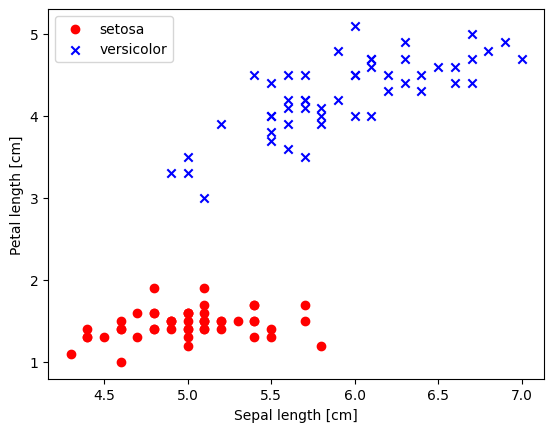

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# select Setosa and Versicolor
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', 0, 1)

# extract sepal lenght and petal length
X = df.iloc[0:100, [0, 2]].values

# plot data
plt.scatter(X[:50, 0], X[:50, 1],
            color='red',
            marker='o',
            label='setosa')
plt.scatter(X[50:100, 0], X[50:100, 1],
            color='blue',
            marker='x',
            label='versicolor')

plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')

plt.show()

### Training the perceptron model

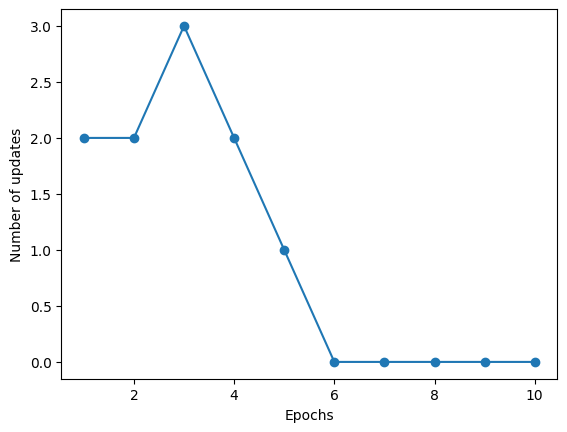

In [7]:
ppn = Perceptron(eta=0.1, n_iter=10)

ppn.fit(X, y)

plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of updates')

plt.show()

### Plotting decision regions.

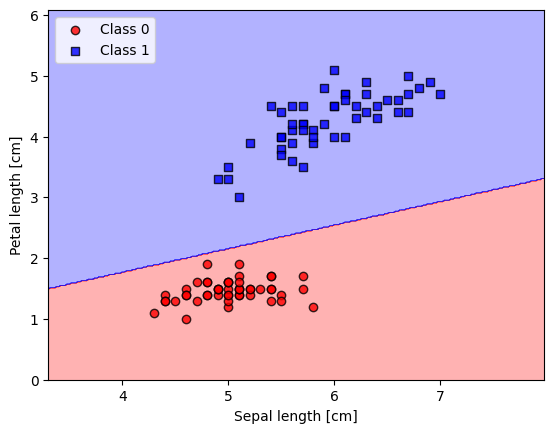

In [8]:
plot_decision_regions(X, y, classifier=ppn)
plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')

plt.show()